1. Implement and verify the Bernstein–Vazirani algorithm in Colab.

In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=ad42b9a191551d1019474a49167c71ce4ea51122c317b04c103496e7ce599581
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


{'011': 1024}


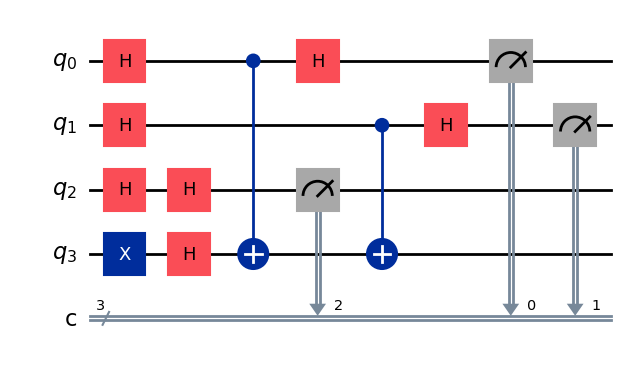

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer

# Hidden string
s = "110"
n = len(s)

qc = QuantumCircuit(n + 1, n)

# Step 1: Prepare output qubit in |1>
qc.x(n)
qc.h(n)

# Step 2: Apply Hadamard to input qubits only
for i in range(n):
    qc.h(i)

# Step 3: Oracle
for i in range(n):
    if s[i] == '1':
        qc.cx(i, n)

# Step 4: Apply Hadamard again to input qubits
for i in range(n):
    qc.h(i)

# Step 5: Measure
qc.measure(range(n), range(n))

# Run
backend = Aer.get_backend("qasm_simulator")
result = backend.run(qc, shots=1024).result()

print(result.get_counts())
qc.draw('mpl')